In [3]:
# Librerias
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_theme(rc = {'figure.figsize': (12,6)}, style = 'darkgrid')
print("Librerías cargadas")


Librerías cargadas


In [4]:
# Datasets
df = pd.read_csv('../data/processed/tmdb_clean.csv')
df_genres = pd.read_csv('../data/processed/genre_counts.csv')
df_genre_roi = pd.read_csv('../data/processed/genre_roi.csv')
movies_per_decade = pd.read_csv('../data/processed/movies_per_decade.csv')
avg_runtime = pd.read_csv('../data/processed/avg_runtime.csv')
top_movies = pd.read_csv('../data/processed/top_movies.csv')

print("Datasets cargados")
print(f"Dataset principal: {df.shape}")

Datasets cargados
Dataset principal: (3229, 18)


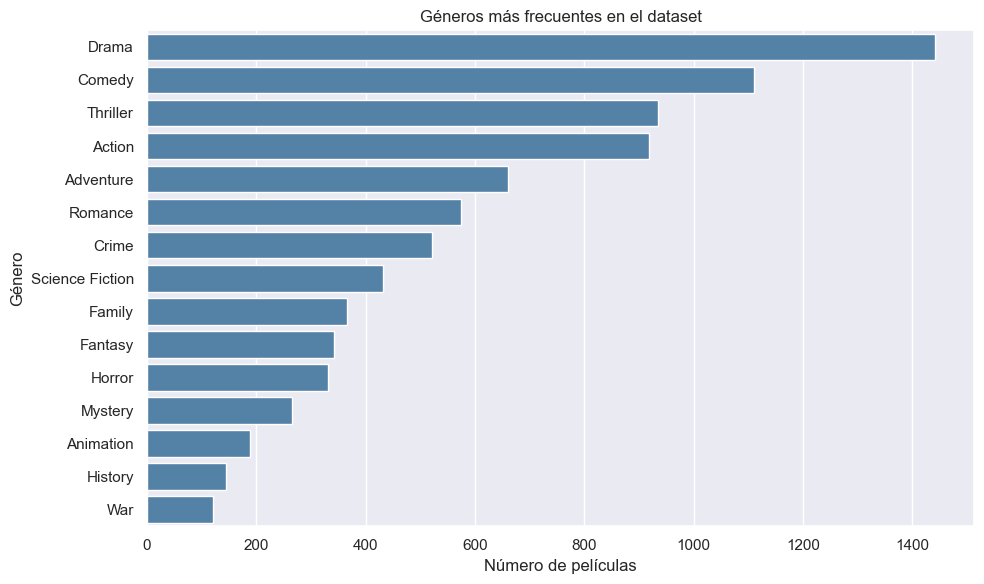

In [5]:
# Gráfica, Géneros más frecuentes 
plt.figure(figsize=(10, 6))
sns.barplot(data=df_genres.sort_values('count', ascending=False), x='count', y='genre', color='steelblue')
plt.title('Géneros más frecuentes en el dataset')
plt.xlabel('Número de películas')
plt.ylabel('Género')
plt.tight_layout()
plt.savefig('../visualizations/01_generos_frecuentes.png', dpi=150, bbox_inches='tight')
plt.show()

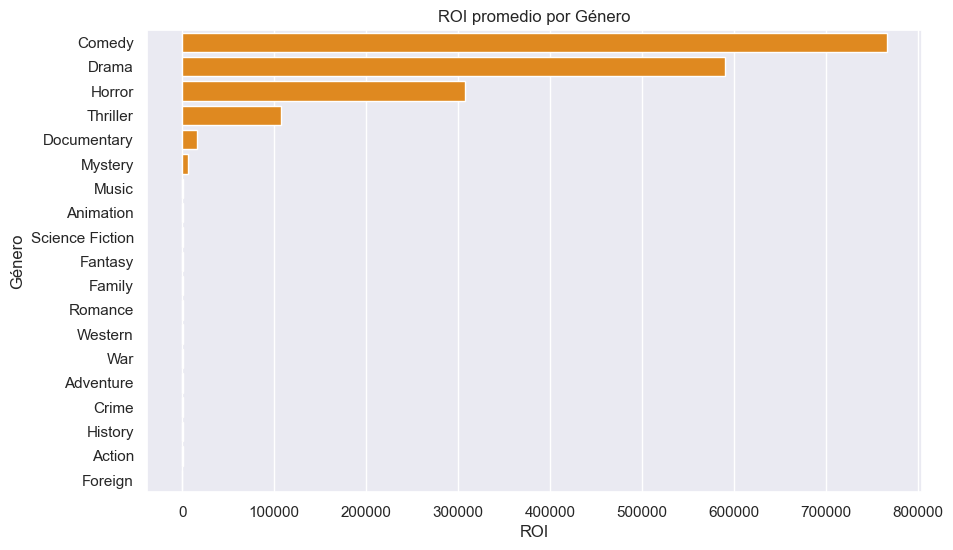

In [6]:
# ROI promedio por genero
plt.figure(figsize=(10,6))
sns.barplot(data=df_genre_roi.sort_values('avg_roi', ascending = False), x = 'avg_roi', y = 'genre', color = 'darkorange')
plt.title('ROI promedio por Género')
plt.xlabel('ROI')
plt.ylabel('Género')
plt.savefig('../visualizations/02_ROI_por_genero.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [11]:
import ast

df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

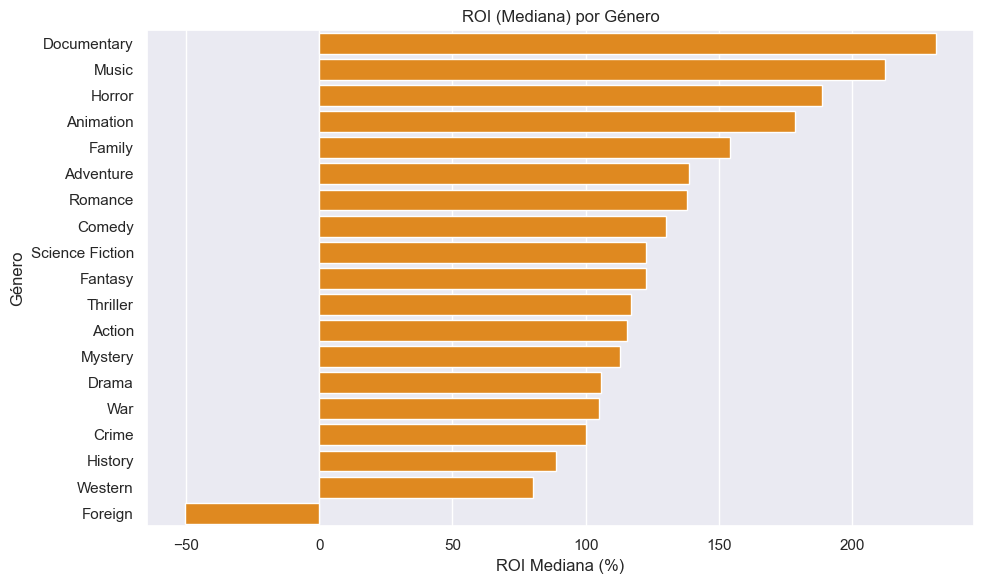

In [12]:
df_genre_roi_median = (
    df.explode('genres')
      .groupby('genres', as_index=False)['roi']
      .median()
      .round(2)
      .sort_values('roi', ascending=False)
)
df_genre_roi_median.columns = ['genre', 'median_roi']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_genre_roi_median, x='median_roi', y='genre', color='darkorange')
plt.title('ROI (Mediana) por Género')
plt.xlabel('ROI Mediana (%)')
plt.ylabel('Género')
plt.tight_layout()
plt.savefig('../visualizations/02_roi_por_genero.png', dpi=150, bbox_inches='tight')
plt.show()

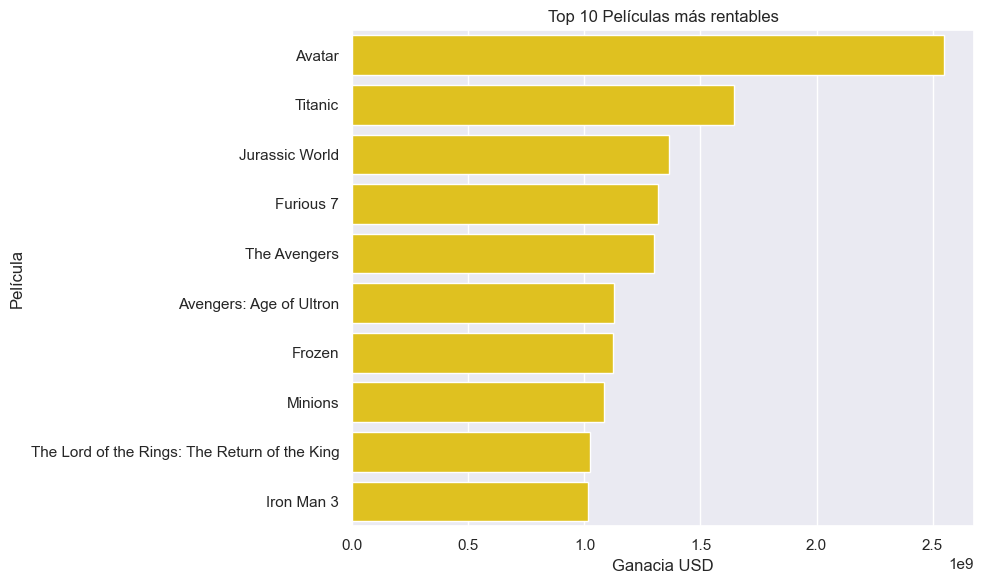

In [8]:
# Top Peliculas mas rentables del dataset
plt.figure(figsize = (10,6))
sns.barplot(data = top_movies, x = 'net_profit', y = 'title', color = 'gold')
plt.title("Top 10 Películas más rentables")
plt.ylabel("Película")
plt.xlabel("Ganacia USD")
plt.tight_layout()
plt.savefig('../visualizations/03_top_peliculas_rentables.png', dpi = 150, bbox_inches = 'tight')
plt.show()

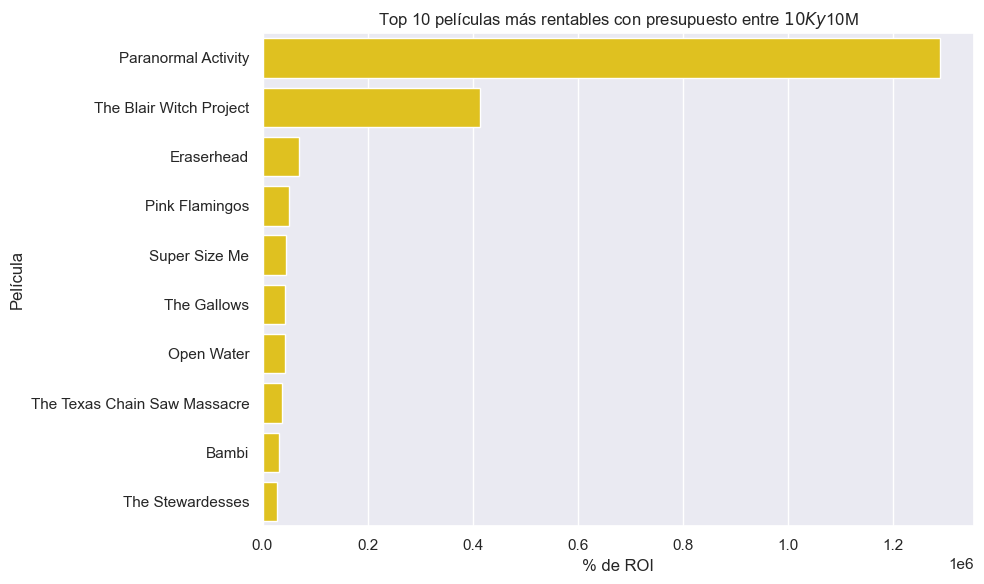

In [14]:
# Top Peliculas de bajo presupuesto más rentables (10mil a 10m)
top_lowbudget_10m = (
    df[(df['budget'] >= 10_000) & (df['budget'] < 10_000_000)].sort_values('roi', ascending=False).head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_lowbudget_10m, x='roi', y='title', color='gold')
plt.title('Top 10 películas más rentables con presupuesto entre $10K y $10M')
plt.xlabel('% de ROI')
plt.ylabel('Película')
plt.tight_layout()
plt.savefig('../visualizations/03_top_bajo_presupuesto_10m.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print(top_lowbudget_10m[['title', 'budget', 'revenue', 'roi']])

                        title  budget    revenue           roi
3078             Modern Times       1    8500000  8.499999e+08
2522                Nurse 3-D      10   10000000  9.999990e+07
3173      Paranormal Activity   15000  193355800  1.288939e+06
3175                Tarnation     218    1162014  5.329339e+05
3157  The Blair Witch Project   60000  248000000  4.132333e+05
3218               Eraserhead   10000    7000000  6.990000e+04
3225           Pink Flamingos   12000    6000000  4.990000e+04
3220            Super Size Me   65000   28575078  4.386166e+04
3217              The Gallows  100000   42664410  4.256441e+04
3161               Open Water  130000   54667954  4.195227e+04


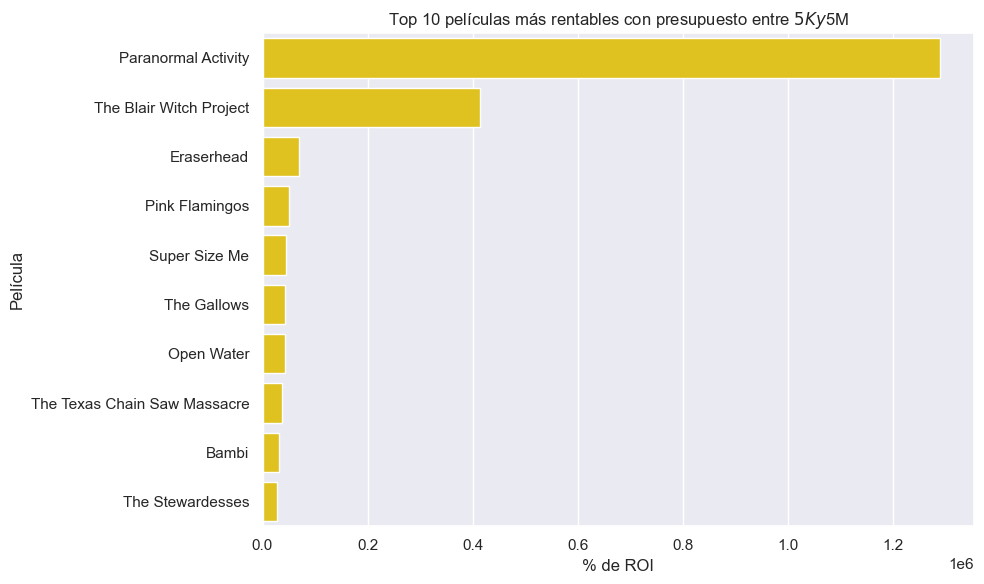

In [15]:
# Top Peliculas de bajo presupuesto más rentables (5mil a 5m)
top_lowbudget_5m = (
    df[(df['budget'] >= 5_000) & (df['budget'] < 5_000_000)].sort_values('roi', ascending=False).head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_lowbudget_10m, x='roi', y='title', color='gold')
plt.title('Top 10 películas más rentables con presupuesto entre $5k y $5M')
plt.xlabel('% de ROI')
plt.ylabel('Película')
plt.tight_layout()
plt.savefig('../visualizations/03_top_bajo_presupuesto_5m.png', dpi=150, bbox_inches='tight')
plt.show()

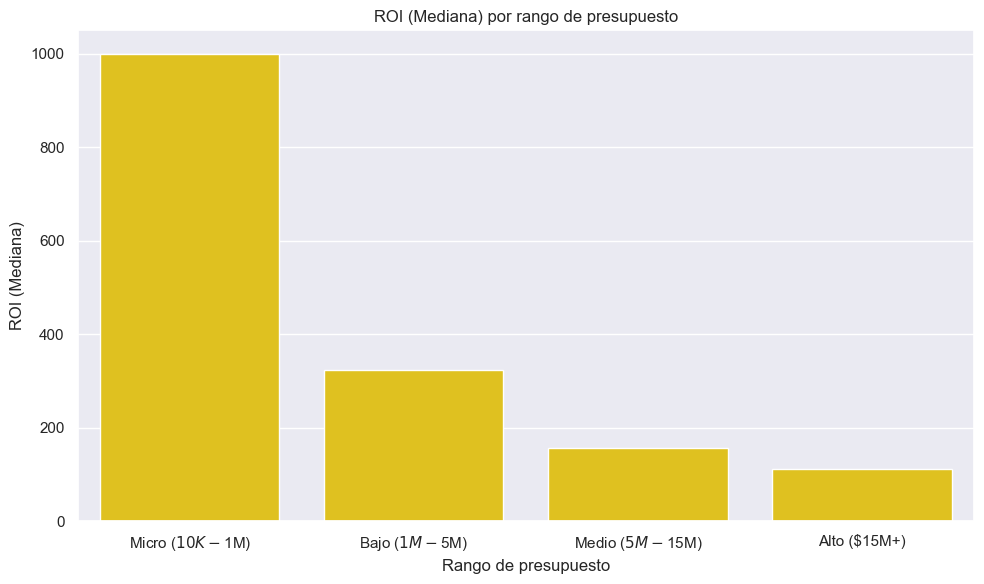

In [16]:
def budget_range(budget):
    if budget < 1_000_000:
        return 'Micro ($10K-$1M)'
    elif budget < 5_000_000:
        return 'Bajo ($1M-$5M)'
    elif budget < 15_000_000:
        return 'Medio ($5M-$15M)'
    else:
        return 'Alto ($15M+)'

df_indie = df[df['budget'] >= 10_000].copy()
df_indie['budget_range'] = df_indie['budget'].apply(budget_range)

median_roi_by_range = (
    df_indie.groupby('budget_range', as_index=False)['roi']
    .median()
    .round(2)
)

order_categories = ['Micro ($10K-$1M)', 'Bajo ($1M-$5M)', 'Medio ($5M-$15M)', 'Alto ($15M+)']

plt.figure(figsize=(10, 6))
sns.barplot(data=median_roi_by_range, x='budget_range', y='roi', color='gold', order=order_categories)

plt.title('ROI (Mediana) por rango de presupuesto')
plt.xlabel('Rango de presupuesto')
plt.ylabel('ROI (Mediana)')
plt.tight_layout()
plt.savefig('../visualizations/04_roi_por_rango_presupuesto.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Rentabilidad vs Riesgo por género
genres_performance = (
    df[(df['budget'] >= 10_000) & (df['budget'] < 5_000_000)]
    .explode('genres')
    .groupby('genres', as_index=False)['roi']
    .agg(['median', 'std', 'count'])
    .round(2)
)
genres_performance.columns = ['genre', 'median_roi', 'roi_std', 'movie_count']
genres_performance = genres_performance[genres_performance['movie_count'] >= 5]

genres_performance['risk_ratio'] = (genres_performance['roi_std'] / genres_performance['median_roi']).round(2)
genres_performance = genres_performance.sort_values('risk_ratio', ascending=True).reset_index(drop=True)

print(genres_performance)

              genre  median_roi    roi_std  movie_count  risk_ratio
0           History      653.46    1621.89           18        2.48
1         Animation     3554.39   12539.79            5        3.53
2         Adventure     1009.63    5292.88           22        5.24
3           Romance      362.50    2260.85           85        6.24
4             Music      425.78    3064.87           19        7.20
5               War      440.38    3523.28           12        8.00
6           Western      237.50    1917.51           17        8.07
7            Family      893.50    9016.62           12       10.09
8            Action      300.00    3618.68           57       12.06
9          Thriller      457.26    7119.13           91       15.57
10           Comedy      415.96    6708.27          122       16.13
11            Drama      343.28    6847.90          216       19.95
12            Crime      236.10    6488.07           60       27.48
13  Science Fiction      403.14   11840.11      

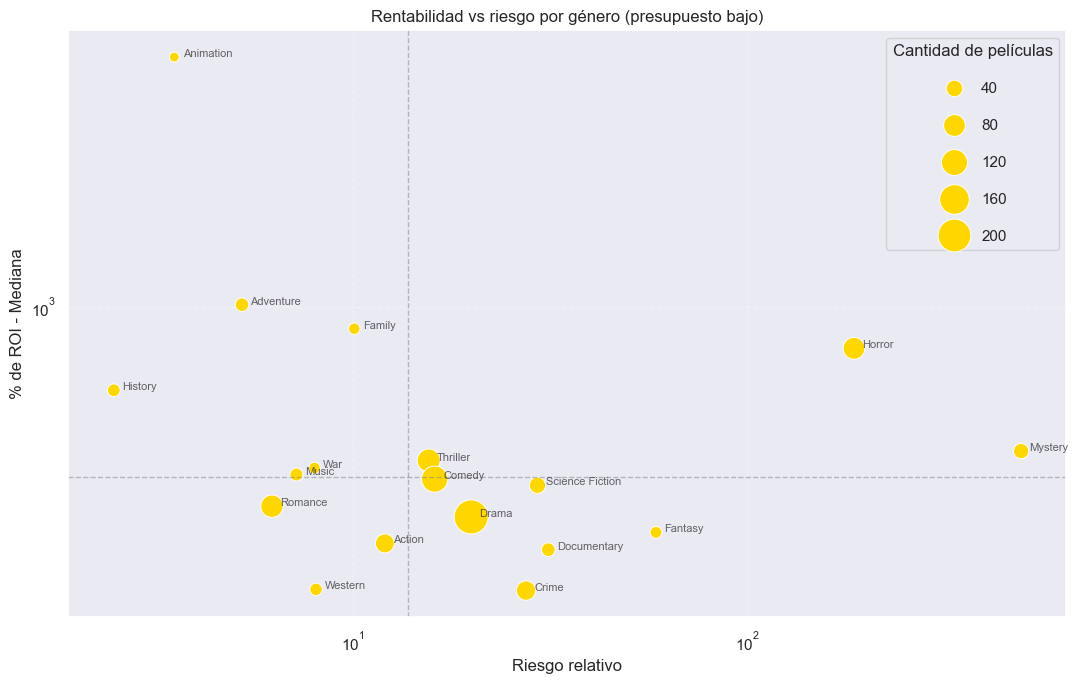

In [28]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=genres_performance,
    x='risk_ratio',
    y='median_roi',
    size='movie_count',
    sizes=(50, 600),
    color='gold',
    legend='brief'
)
for _, row in genres_performance.iterrows():
    plt.text(row['risk_ratio'] * 1.05, row['median_roi'], row['genre'], fontsize=8, alpha=0.7)
plt.axvline(genres_performance['risk_ratio'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.axhline(genres_performance['median_roi'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.xscale('log')
plt.yscale('log')
plt.legend(title = 'Cantidad de películas', labelspacing = 1.5)
plt.title('Rentabilidad vs riesgo por género (presupuesto bajo)')
plt.xlabel('Riesgo relativo')
plt.ylabel('% de ROI - Mediana')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../visualizations/05_riesgo_vs_rentabilidad_genero.png', dpi=150, bbox_inches='tight')
plt.show()